In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/urinary_stone_project"
RAW_DIR = f"{PROJECT_DIR}/raw_data"
WORK_DIR = f"{PROJECT_DIR}/phase1_classification"
SPLIT_DIR = f"{WORK_DIR}/dataset_split"

for p in [PROJECT_DIR, RAW_DIR, WORK_DIR, SPLIT_DIR]:
    os.makedirs(p, exist_ok=True)

print("Folders ready.")
print("PROJECT_DIR =", PROJECT_DIR)

Folders ready.
PROJECT_DIR = /content/drive/MyDrive/urinary_stone_project


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"puntharathirani","key":"a0b97de56b8d9bff30810b65071a1701"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured.")

Kaggle API configured.


In [ ]:
!kaggle datasets download -d fahadahmed187/kub-x-ray-images-for-kidney-stone-identification -p /content/

Dataset URL: https://www.kaggle.com/datasets/fahadahmed187/kub-x-ray-images-for-kidney-stone-identification
License(s): unknown
100% 159M/159M [00:01<00:00, 103MB/s]



In [ ]:
import zipfile

zip_path = "/content/kub-x-ray-images-for-kidney-stone-identification.zip"
extract_path = f"{RAW_DIR}/kub_xray_original"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/drive/MyDrive/urinary_stone_project/raw_data/kub_xray_original


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")
    if len(files) > 10:
        print(f"{subindent}... ({len(files)} files)")

kub_xray_original/
  Kidney Stone KUB X-Rays/
    1. Normal/
      101.png
      1013.png
      1017.png
      1039.png
      1041.png
      1051.png
      1053.png
      1061.png
      1068.png
      1075.png
      ... (250 files)
    2. Kidney  Stone/
      1007.png
      1022.png
      104.png
      1042.png
      1043.png
      1049.png
      1064.png
      1072.png
      1078.png
      1106.png
      ... (250 files)


In [ ]:
import os

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

candidate_class_dirs = []

for root, dirs, files in os.walk(extract_path):
    image_files = [f for f in files if os.path.splitext(f.lower())[1] in image_exts]
    if len(image_files) > 0:
        candidate_class_dirs.append((root, len(image_files)))

print("Candidate image folders:")
for path, count in candidate_class_dirs:
    print(f"{path} -> {count} images")

Candidate image folders:
/content/drive/MyDrive/urinary_stone_project/raw_data/kub_xray_original/Kidney Stone KUB X-Rays/1. Normal -> 250 images
/content/drive/MyDrive/urinary_stone_project/raw_data/kub_xray_original/Kidney Stone KUB X-Rays/2. Kidney  Stone -> 250 images


In [ ]:
import os

BASE = "/content/drive/MyDrive/urinary_stone_project/raw_data/kub_xray_original/Kidney Stone KUB X-Rays"

old_normal = os.path.join(BASE, "1. Normal")
old_stone = os.path.join(BASE, "2. Kidney  Stone")

new_normal = os.path.join(BASE, "normal")
new_stone = os.path.join(BASE, "stone")

# rename
os.rename(old_normal, new_normal)
os.rename(old_stone, new_stone)

print("Renamed successfully ✅")

Renamed successfully ✅


In [ ]:
print(os.listdir(BASE))

['normal', 'stone']


In [ ]:
STONE_SRC = "/content/drive/MyDrive/urinary_stone_project/raw_data/kub_xray_original/Kidney Stone KUB X-Rays/stone"
NORMAL_SRC = "/content/drive/MyDrive/urinary_stone_project/raw_data/kub_xray_original/Kidney Stone KUB X-Rays/normal"

print(os.path.exists(STONE_SRC))
print(os.path.exists(NORMAL_SRC))

True
True


In [ ]:
import os
import hashlib

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def remove_duplicates(folder):
    seen = {}
    removed = []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if not os.path.isfile(fpath):
            continue
        try:
            h = file_hash(fpath)
            if h in seen:
                os.remove(fpath)
                removed.append(fpath)
            else:
                seen[h] = fpath
        except Exception as e:
            print("Error:", fpath, e)
    return removed

removed_stone = remove_duplicates(STONE_SRC)
removed_normal = remove_duplicates(NORMAL_SRC)

print("Removed stone duplicates:", len(removed_stone))
print("Removed normal duplicates:", len(removed_normal))

Removed stone duplicates: 0
Removed normal duplicates: 0


In [ ]:
from PIL import Image

def remove_corrupt_images(folder):
    removed = []
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if not os.path.isfile(fpath):
            continue
        try:
            with Image.open(fpath) as img:
                img.verify()
        except Exception:
            os.remove(fpath)
            removed.append(fpath)
    return removed

bad_stone = remove_corrupt_images(STONE_SRC)
bad_normal = remove_corrupt_images(NORMAL_SRC)

print("Removed corrupt stone images:", len(bad_stone))
print("Removed corrupt normal images:", len(bad_normal))

Removed corrupt stone images: 0
Removed corrupt normal images: 0


In [ ]:
def count_images(folder):
    return len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])

stone_count = count_images(STONE_SRC)
normal_count = count_images(NORMAL_SRC)

print("Stone images:", stone_count)
print("Normal images:", normal_count)

Stone images: 250
Normal images: 250


In [ ]:
import os
import shutil
import random
from math import floor

random.seed(42)

base_out = SPLIT_DIR
classes = {
    "stone": STONE_SRC,
    "normal": NORMAL_SRC
}

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(base_out, split, cls), exist_ok=True)

def split_files(file_list, train_ratio=0.70, val_ratio=0.15):
    random.shuffle(file_list)
    n = len(file_list)
    n_train = floor(n * train_ratio)
    n_val = floor(n * val_ratio)
    train_files = file_list[:n_train]
    val_files = file_list[n_train:n_train+n_val]
    test_files = file_list[n_train+n_val:]
    return train_files, val_files, test_files

for cls, src in classes.items():
    files = [
        f for f in os.listdir(src)
        if os.path.isfile(os.path.join(src, f))
    ]

    train_files, val_files, test_files = split_files(files)

    for split_name, split_files_list in {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }.items():
        for fname in split_files_list:
            src_path = os.path.join(src, fname)
            dst_path = os.path.join(base_out, split_name, cls, fname)
            shutil.copy2(src_path, dst_path)

print("Dataset split complete.")

Dataset split complete.


In [ ]:
for split in ["train", "val", "test"]:
    for cls in ["stone", "normal"]:
        folder = os.path.join(SPLIT_DIR, split, cls)
        count = len(os.listdir(folder))
        print(split, cls, count)

train stone 175
train normal 175
val stone 37
val normal 37
test stone 38
test normal 38


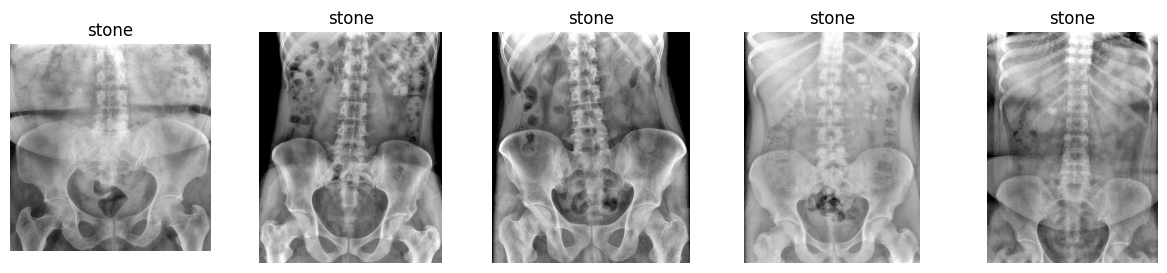

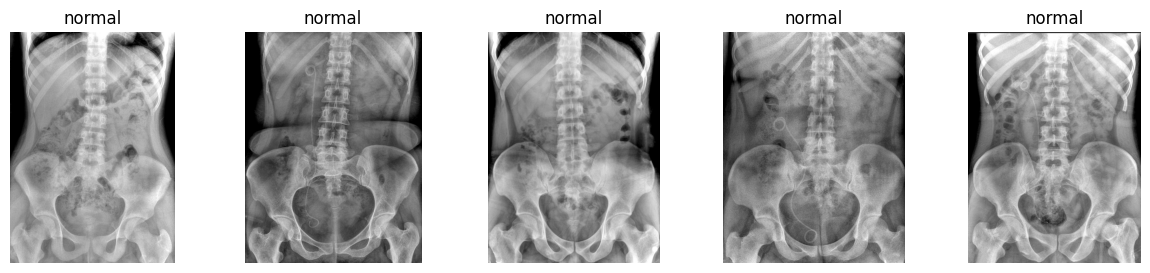

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def show_samples(folder, title, n=5):
    files = os.listdir(folder)
    samples = random.sample(files, min(n, len(files)))
    plt.figure(figsize=(15,3))
    for i, fname in enumerate(samples, 1):
        img = Image.open(os.path.join(folder, fname)).convert("L")
        plt.subplot(1, len(samples), i)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(title)
    plt.show()

show_samples(f"{SPLIT_DIR}/train/stone", "stone")
show_samples(f"{SPLIT_DIR}/train/normal", "normal")

In [ ]:
!pip install -q torch torchvision scikit-learn

In [ ]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
DATA_DIR = "/content/drive/MyDrive/urinary_stone_project/phase1_classification/dataset_split"

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

print(train_dir)
print(val_dir)
print(test_dir)

/content/drive/MyDrive/urinary_stone_project/phase1_classification/dataset_split/train
/content/drive/MyDrive/urinary_stone_project/phase1_classification/dataset_split/val
/content/drive/MyDrive/urinary_stone_project/phase1_classification/dataset_split/test


In [ ]:
input_size = 224
batch_size = 16

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((input_size, input_size)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['normal', 'stone']
Train size: 350
Val size: 74
Test size: 76


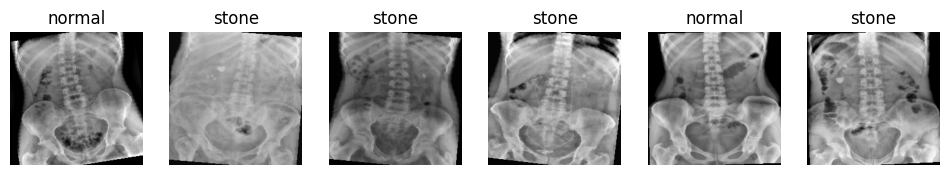

In [ ]:
def show_batch(loader):
    images, labels = next(iter(loader))
    images = images[:6]
    labels = labels[:6]

    plt.figure(figsize=(12, 4))
    for i in range(len(images)):
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

show_batch(train_loader)

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = running_corrects.double() / len(loader.dataset)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.cpu().item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.cpu().item())

                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        scheduler.step()

    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed/60:.2f} minutes")
    print(f"Best val Acc: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, train_loss_history, val_loss_history, train_acc_history, val_acc_history

In [ ]:
model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist = train_model(
    model, criterion, optimizer, scheduler, num_epochs=15
)


Epoch 1/15
------------------------------
Train Loss: 0.6711 Acc: 0.6171
Val Loss: 0.6582 Acc: 0.5541

Epoch 2/15
------------------------------
Train Loss: 0.5079 Acc: 0.7057
Val Loss: 0.4893 Acc: 0.8108

Epoch 3/15
------------------------------
Train Loss: 0.3858 Acc: 0.8486
Val Loss: 0.2921 Acc: 0.9054

Epoch 4/15
------------------------------
Train Loss: 0.1932 Acc: 0.9371
Val Loss: 0.3242 Acc: 0.7973

Epoch 5/15
------------------------------
Train Loss: 0.2886 Acc: 0.8971
Val Loss: 0.2784 Acc: 0.8649

Epoch 6/15
------------------------------
Train Loss: 0.2326 Acc: 0.9171
Val Loss: 0.3528 Acc: 0.8784

Epoch 7/15
------------------------------
Train Loss: 0.1911 Acc: 0.9343
Val Loss: 0.5786 Acc: 0.8108

Epoch 8/15
------------------------------
Train Loss: 0.1526 Acc: 0.9486
Val Loss: 0.3038 Acc: 0.8649

Epoch 9/15
------------------------------
Train Loss: 0.1489 Acc: 0.9371
Val Loss: 0.2272 Acc: 0.9189

Epoch 10/15
------------------------------
Train Loss: 0.1304 Acc: 0.951

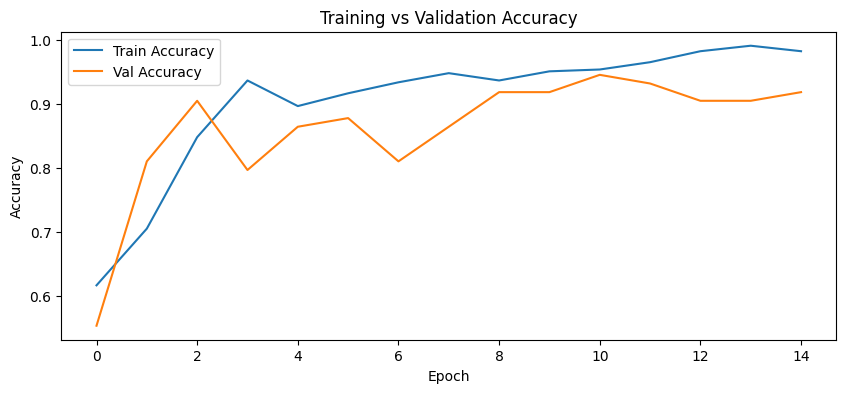

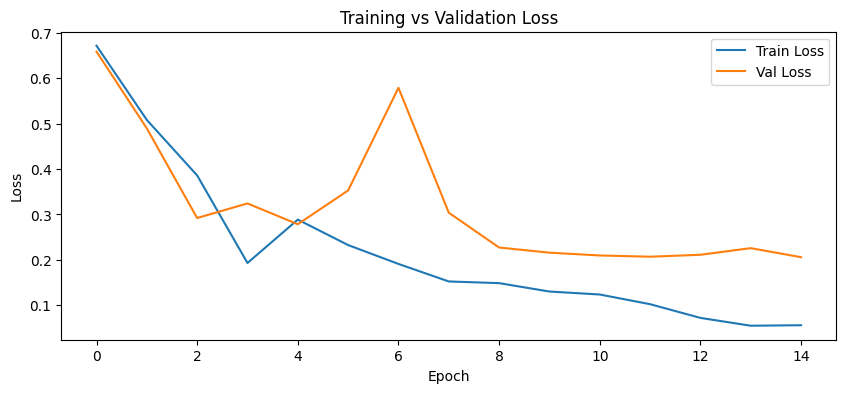

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(val_acc_hist, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      normal       0.93      0.97      0.95        38
       stone       0.97      0.92      0.95        38

    accuracy                           0.95        76
   macro avg       0.95      0.95      0.95        76
weighted avg       0.95      0.95      0.95        76



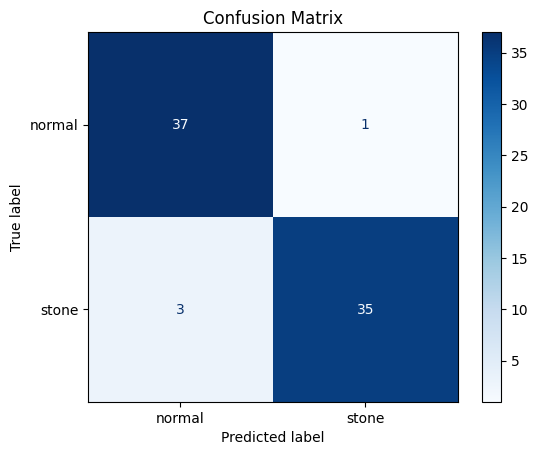

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 94.74%


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/urinary_stone_project/phase1_classification/efficientnet_b0_kidney_stone.pth"
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/urinary_stone_project/phase1_classification/efficientnet_b0_kidney_stone.pth
